In [3]:
from pathlib import Path
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [4]:
# Set the project root to the parent of the current working directory
PROJECT_ROOT = Path.cwd().parent

# Create the path to the original, unprocessed dataset
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

# Create the path where processed MRI data will be stored
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

# Create the processed data directory if it does not already exist
PROCESSED_DIR.mkdir(
    parents=True,   # Create any missing parent folders
    exist_ok=True   # Do not raise an error if the folder already exists
)

# Display the location of the raw dataset
print("Raw data:")
print(RAW_DATA_DIR)

# Display the location of the processed dataset
print("\nProcessed data:")
print(PROCESSED_DIR)

Raw data:
/Users/paulcollingwood/Documents/Source/parkinsons_ml/data/raw

Processed data:
/Users/paulcollingwood/Documents/Source/parkinsons_ml/data/processed


In [6]:
# Find all NIfTI MRI files inside the raw data directory
nifti_files = [
    file
    for file in RAW_DATA_DIR.rglob("*")
    if file.name.lower().endswith((".nii", ".nii.gz"))
]

# Display the total number of NIfTI files found
print(f"NIfTI files found: {len(nifti_files)}")

NIfTI files found: 688


In [8]:
# Display the first 10 NIfTI files found in the raw dataset
for file in nifti_files[:10]:

    # Print each file path relative to the raw data directory
    # This keeps the output shorter and easier to read
    print(file.relative_to(RAW_DATA_DIR))

mri_datscan_ppmi/datscan b.tech/control/PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_3563_NM_Reconstructed_DaTSCAN_Br_20121011135001960_1_S131286_I339559.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_3270_NM_Reconstructed_DaTSCAN_Br_20121018134659840_1_S124326_I341074.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_139138_NM_Reconstructed_DaTSCAN_Br_20220428101444617_1_S1128612_I1574634.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_121621_NM_Reconstructed_DaTSCAN_Br_20220110100814312_1_S1094231_I1531391.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_3857_NM_Reconstructed_DaTSCAN_Br_20121002162142065_1_S127580_I337837.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_3966_NM_Reconstructed_DaTSCAN_Br_20130909140447954_1_S191678_I388574.nii
mri_datscan_ppmi/datscan b.tech/control/PPMI_118726_NM_Reconstructed_DaTSCAN_Br_20220103151010900_1_S1092680_I1529627.nii
mri_datscan_ppmi/datscan b.tech/control/

In [10]:
# Select the first NIfTI file found in the dataset
example_file = nifti_files[0]

# Load the NIfTI MRI file using nibabel
image = nib.load(example_file)

# Convert the MRI data into a NumPy array
volume = image.get_fdata()

# Display the full path of the MRI file being examined
print("File:")
print(example_file)

# Display the dimensions of the MRI volume
print("\nShape:")
print(volume.shape)

# Display the NumPy data type used for the MRI values
print("\nData type:")
print(volume.dtype)

# Display the minimum voxel intensity in the MRI volume
print("\nMinimum:")
print(volume.min())

# Display the maximum voxel intensity in the MRI volume
print("\nMaximum:")
print(volume.max())

File:
/Users/paulcollingwood/Documents/Source/parkinsons_ml/data/raw/mri_datscan_ppmi/datscan b.tech/control/PPMI_203684_NM_Reconstructed_DaTSCAN_Br_20230324105257550_1_S1207834_I1682345.nii

Shape:
(91, 109, 91)

Data type:
float64

Minimum:
0.0

Maximum:
32767.0


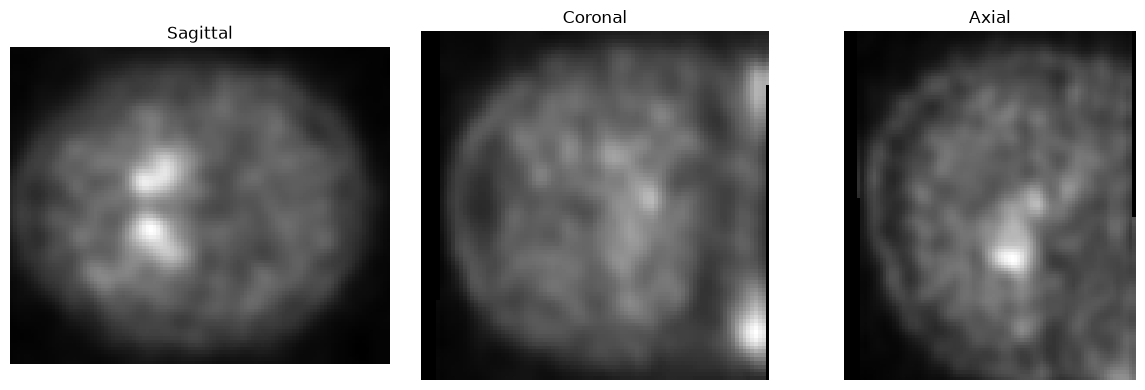

In [12]:
# Find the centre position along each dimension of the MRI volume
x = volume.shape[0] // 2
y = volume.shape[1] // 2
z = volume.shape[2] // 2

# Create a figure with three MRI views displayed side by side
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Display the middle sagittal slice
axes[0].imshow(
    volume[x, :, :].T,
    cmap="gray",
    origin="lower"
)
axes[0].set_title("Sagittal")

# Display the middle coronal slice
axes[1].imshow(
    volume[:, y, :].T,
    cmap="gray",
    origin="lower"
)
axes[1].set_title("Coronal")

# Display the middle axial slice
axes[2].imshow(
    volume[:, :, z].T,
    cmap="gray",
    origin="lower"
)
axes[2].set_title("Axial")

# Remove the axes and tick marks from all three images
for ax in axes:
    ax.axis("off")

# Adjust the spacing between the plots
plt.tight_layout()

# Display the MRI views
plt.show()

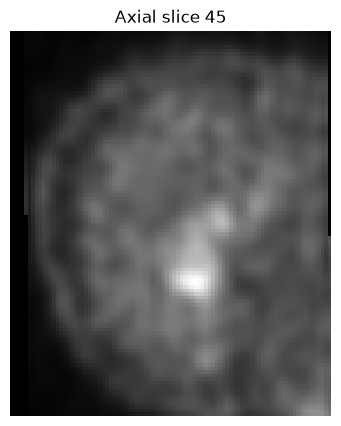

In [14]:
# Find the index of the middle slice along the axial dimension
z = volume.shape[2] // 2

# Extract the middle axial slice from the 3D MRI volume
axial_slice = volume[:, :, z]

# Create a square figure for displaying the slice
plt.figure(figsize=(5, 5))

# Display the axial MRI slice in grayscale
plt.imshow(
    axial_slice.T,
    cmap="gray",
    origin="lower"
)

# Add a title showing the slice number
plt.title(f"Axial slice {z}")

# Hide the axis labels and tick marks
plt.axis("off")

# Display the image
plt.show()

In [16]:
# Define a function to normalise an MRI slice
def normalise_slice(image_slice):

    # Convert the image data to 32-bit floating point values
    image_slice = image_slice.astype(np.float32)

    # Find the minimum and maximum intensity values in the slice
    min_value = image_slice.min()
    max_value = image_slice.max()

    # Avoid division by zero if every pixel has the same value
    if max_value == min_value:
        return np.zeros_like(image_slice)

    # Scale all pixel values to the range 0 to 1
    normalised = (
        image_slice - min_value
    ) / (
        max_value - min_value
    )

    # Return the normalised MRI slice
    return normalised

In [18]:
# Apply the normalisation function to the selected axial MRI slice
normalised_slice = normalise_slice(axial_slice)

# Display the minimum pixel intensity after normalisation
print("Minimum:", normalised_slice.min())

# Display the maximum pixel intensity after normalisation
print("Maximum:", normalised_slice.max())

Minimum: 0.0
Maximum: 1.0


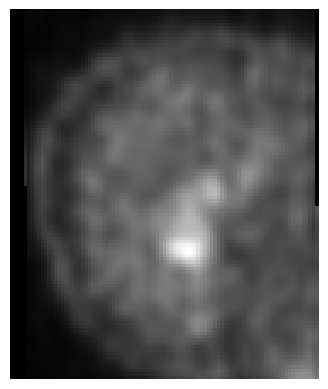

In [20]:
# Display the normalised axial MRI slice
plt.imshow(
    normalised_slice.T,
    cmap="gray",
    origin="lower"
)

# Hide the axis labels and tick marks
plt.axis("off")

# Display the image
plt.show()

In [22]:
# Convert the normalised MRI slice from the 0–1 range to the 0–255 range
image_8bit = (
    normalised_slice * 255
).astype(np.uint8)

In [24]:
# Convert the 8-bit NumPy array into a PIL image
image_pil = Image.fromarray(image_8bit)

# Resize the MRI slice to 224 x 224 pixels
resized_image = image_pil.resize(
    (224, 224)
)

# Convert the resized PIL image back into a NumPy array
resized_array = np.array(resized_image)

# Display the new image dimensions
print(resized_array.shape)

(224, 224)


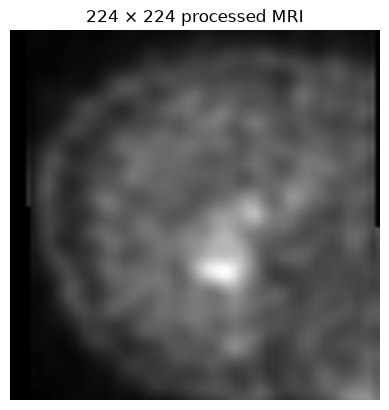

In [26]:
# Display the resized 224 x 224 MRI slice
plt.imshow(
    resized_array.T,
    cmap="gray",
    origin="lower"
)

# Add a title showing the processed image size
plt.title("224 × 224 processed MRI")

# Hide the axis labels and tick marks
plt.axis("off")

# Display the processed MRI image
plt.show()

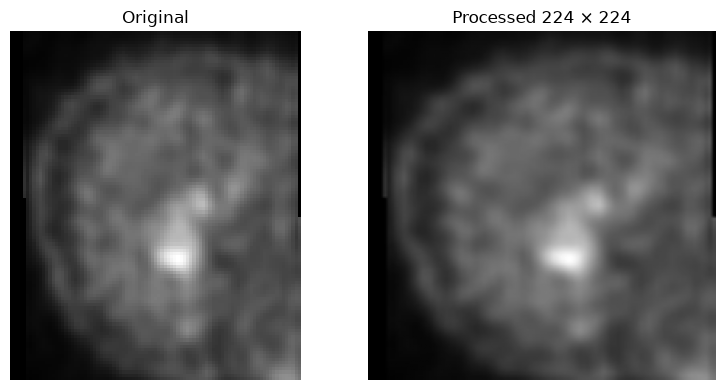

In [28]:
# Create a figure with two images displayed side by side
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Display the original axial MRI slice
axes[0].imshow(
    axial_slice.T,
    cmap="gray",
    origin="lower"
)
axes[0].set_title("Original")

# Display the processed and resized 224 x 224 MRI slice
axes[1].imshow(
    resized_array.T,
    cmap="gray",
    origin="lower"
)
axes[1].set_title("Processed 224 × 224")

# Hide the axis labels and tick marks for both images
for ax in axes:
    ax.axis("off")

# Adjust spacing so the images and titles do not overlap
plt.tight_layout()

# Display the comparison
plt.show()

In [32]:
# Define a function to select several axial slices from around the centre of an MRI volume
def select_axial_slices(volume):

    # Find the index of the centre axial slice
    centre = volume.shape[2] // 2

    # Define how far away from the centre slice to sample
    offsets = [-10, -5, 0, 5, 10]

    # Create an empty list to store the selected slices
    slices = []

    # Loop through each offset value
    for offset in offsets:

        # Calculate the slice index relative to the centre
        index = centre + offset

        # Check that the slice index is within the MRI volume
        if 0 <= index < volume.shape[2]:

            # Store both the slice number and the corresponding 2D MRI slice
            slices.append(
                (index, volume[:, :, index])
            )

    # Return the selected slices
    return slices

In [33]:
# Select several axial slices from around the centre of the MRI volume
selected_slices = select_axial_slices(volume)

# Display the slice numbers that were selected
print(
    [index for index, _ in selected_slices]
)

[35, 40, 45, 50, 55]


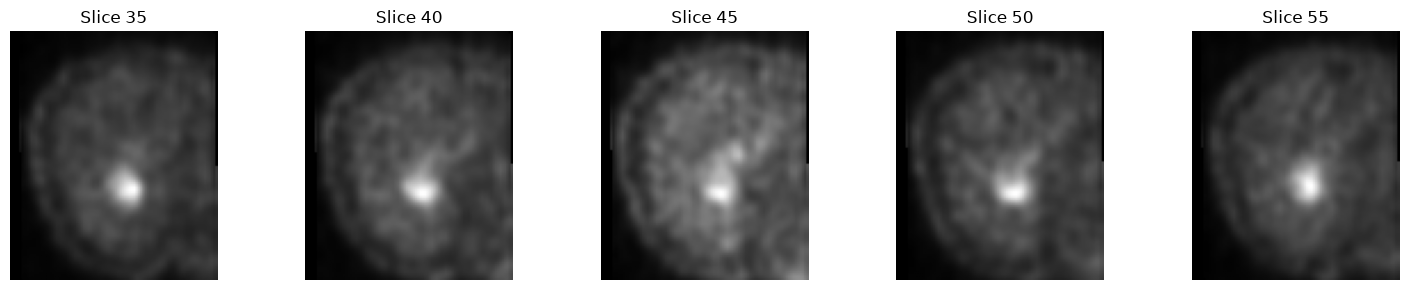

In [34]:
# Create a figure with one subplot for each selected MRI slice
fig, axes = plt.subplots(
    1,
    len(selected_slices),
    figsize=(15, 3)
)

# Loop through each subplot and its corresponding MRI slice
for ax, (index, image_slice) in zip(
    axes,
    selected_slices
):
    # Display the MRI slice in grayscale
    ax.imshow(
        image_slice.T,
        cmap="gray",
        origin="lower"
    )

    # Add the slice number as the title
    ax.set_title(f"Slice {index}")

    # Hide the axis labels and tick marks
    ax.axis("off")

# Adjust spacing between the subplots
plt.tight_layout()

# Display all selected MRI slices
plt.show()

In [36]:
# Define a function to preprocess a single MRI slice
def preprocess_slice(
    image_slice,
    target_size=(224, 224)
):
    # Convert the MRI slice to 32-bit floating-point values
    image_slice = image_slice.astype(np.float32)

    # Find the minimum and maximum intensity values
    min_value = image_slice.min()
    max_value = image_slice.max()

    # Normalise the pixel values to the range 0 to 1
    if max_value > min_value:
        image_slice = (
            image_slice - min_value
        ) / (
            max_value - min_value
        )

    # If all pixel values are identical, return a zero-valued image
    else:
        image_slice = np.zeros_like(image_slice)

    # Convert the normalised image from 0–1 to 0–255
    # and store it as an 8-bit image
    image_8bit = (
        image_slice * 255
    ).astype(np.uint8)

    # Convert the NumPy array into a PIL image
    image_pil = Image.fromarray(image_8bit)

    # Resize the image to the required model input size
    image_pil = image_pil.resize(
        target_size
    )

    # Convert the resized PIL image back into a NumPy array
    return np.array(image_pil)

In [38]:
# Preprocess the middle axial MRI slice using the preprocessing function
processed = preprocess_slice(
    volume[:, :, z]
)

# Display the shape of the processed image
print(processed.shape)

# Display the minimum pixel intensity
print(processed.min())

# Display the maximum pixel intensity
print(processed.max())

(224, 224)
0
255


In [40]:
# Create a path for storing test outputs inside the processed data folder
TEST_OUTPUT_DIR = (
    PROCESSED_DIR
    / "test"
)

# Create the test output directory if it does not already exist
TEST_OUTPUT_DIR.mkdir(
    parents=True,   # Create any missing parent folders
    exist_ok=True   # Do not raise an error if the folder already exists
)

In [42]:
# Create the full path for the processed example MRI image
output_file = (
    TEST_OUTPUT_DIR
    / "example_mri.png"
)

# Convert the processed NumPy array into a PIL image
# and save it as a PNG file
Image.fromarray(
    processed
).save(output_file)

# Display the location of the saved image
print(output_file)

/Users/paulcollingwood/Documents/Source/parkinsons_ml/data/processed/test/example_mri.png
